# Figure 3
Evaluate simulated PM2.5 against measurements from EMEP stations, located in European anthropogenic emission source regions.

In [1]:
from datetime import datetime
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
import numpy as np
import pyproj
import wrfpp

## Read EMEP data and model output

In [2]:
emep = xr.open_dataset("/mnt/data/emep/emep_pm25_processed.nc")
wrfout = xr.open_dataset("/mnt/data/model_output/ACI_OPT_2/PM2_5_DRY.nc").set_index(Time="XTIME")

### extract EMEP stations from model output

In [3]:
wrfout_emep = []
for i in range(len(emep.station)):
    st = emep.station.values[i]
    print(st)
    lon_st, lat_st = emep.sel(station=st).lon.values, emep.sel(station=st).lat.values
    try:
        ds_mean = wrfout.wrf.value_around_point(lon_st, lat_st, method="mean")
        ds_mean = ds_mean.expand_dims({"stat":["mean"], "station":[st]})
        ds_min = wrfout.wrf.value_around_point(lon_st, lat_st, method="min")
        ds_min = ds_min.expand_dims({"stat":["min"], "station":[st]})
        ds_max = wrfout.wrf.value_around_point(lon_st, lat_st, method="max")
        ds_max = ds_max.expand_dims({"stat":["max"], "station":[st]})
        ds_st = xr.concat([ds_mean,ds_min,ds_max], dim="stat")
        wrfout_emep.append(ds_st)
    except ValueError:
        print(f"Error, likely point {lon_st}, {lat_st} outside domain")
wrfout_emep = xr.concat(wrfout_emep, dim="station")
wrfout_emep

Diabla Gora
Illmitz
K-puszta
Melpitz
Montseny
Neuglobsow
Schauinsland
Schmücke
Waldhof
Zielonka


<xarray.Dataset> Size: 7MB
Dimensions:    (stat: 3, station: 10, Time: 1129, bottom_top: 49)
Coordinates:
  * stat       (stat) object 24B 'mean' 'min' 'max'
  * station    (station) object 80B 'Diabla Gora' 'Illmitz' ... 'Zielonka'
  * Time       (Time) datetime64[ns] 9kB 2020-03-15 ... 2020-05-01
Dimensions without coordinates: bottom_top
Data variables:
    PM2_5_DRY  (stat, station, Time, bottom_top) float32 7MB 0.0 0.0 ... 0.1079
Attributes: (12/145)
    TITLE:                            OUTPUT FROM *             PROGRAM:WRF-C...
    START_DATE:                      2020-03-15_00:00:00
    SIMULATION_START_DATE:           2020-03-15_00:00:00
    WEST-EAST_GRID_DIMENSION:        100
    SOUTH-NORTH_GRID_DIMENSION:      100
    BOTTOM-TOP_GRID_DIMENSION:       50
    ...                              ...
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      0
    ETAC:                            0.0
    history:                         Thu Jan 22 09:39:57 2026: ncrcat -v PM2_...
    NCO:                             netCDF Operators version 5.3.6 (Homepage...

## plot PM2.5 time series

In [4]:
wrfout_emep_d = wrfout_emep.resample(Time="1D").mean()

### per station

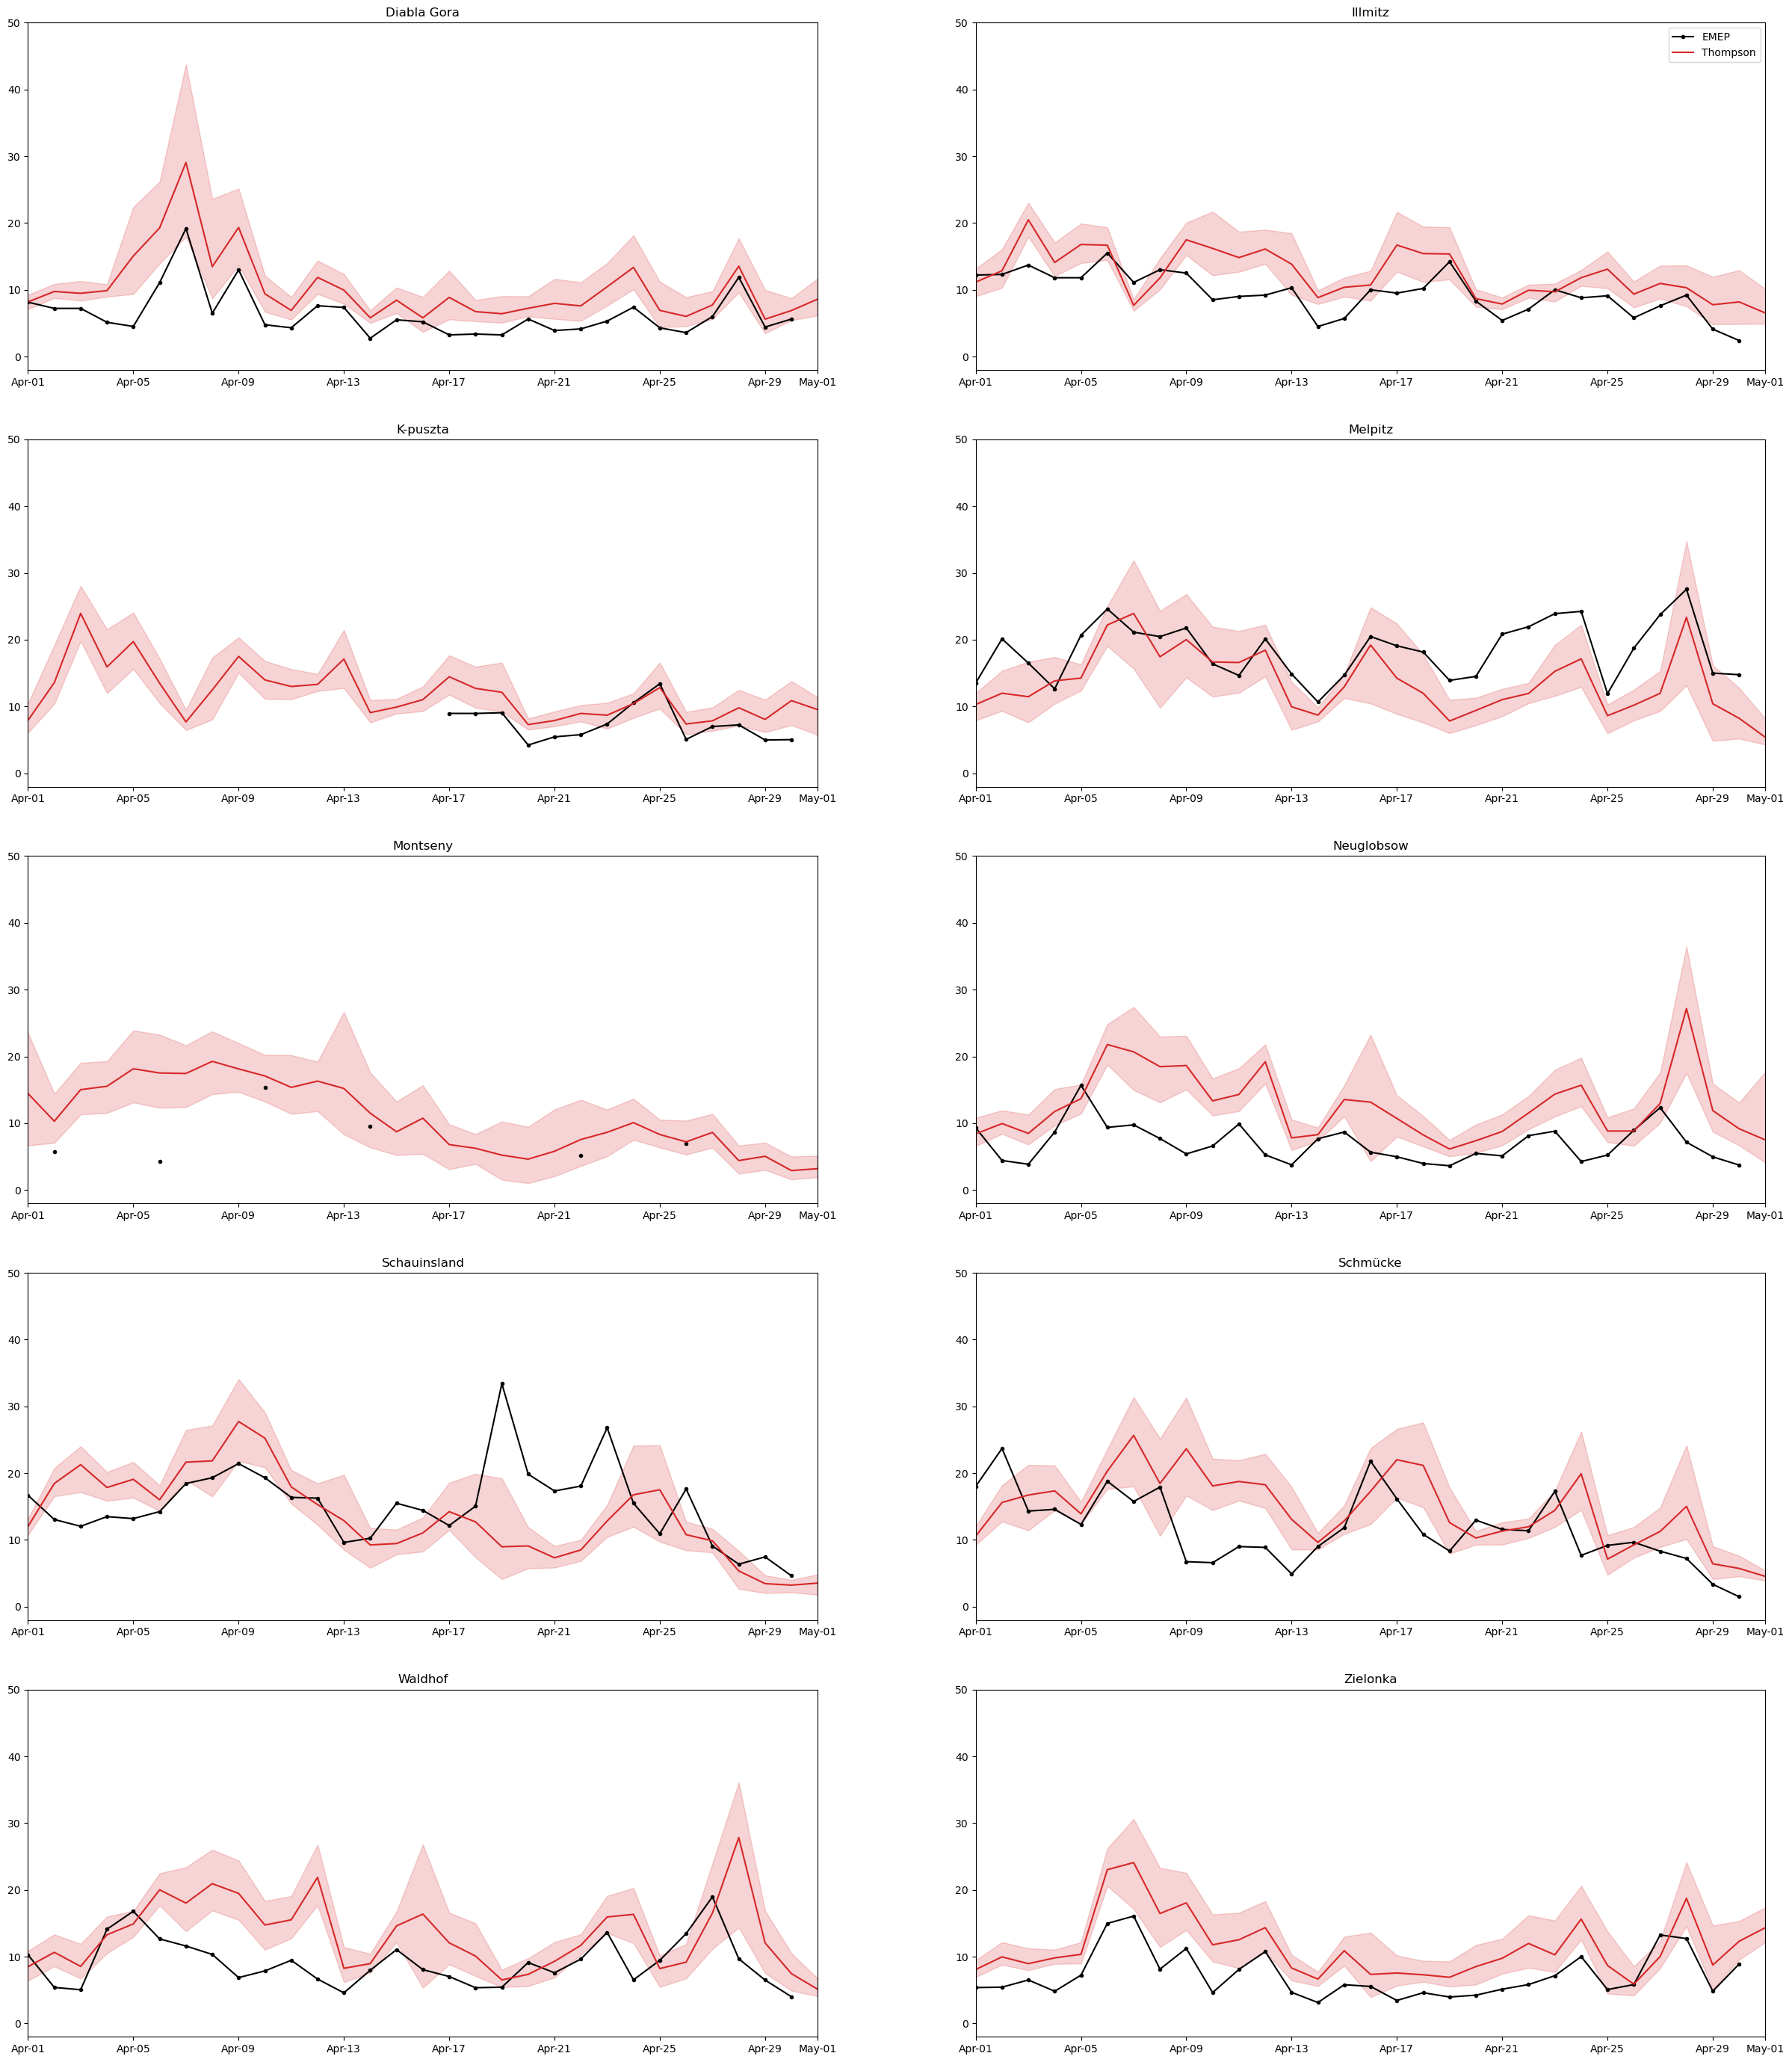

In [5]:
fig, axes = plt.subplots(5, 2, figsize=(30,35))
for i in range(len(emep.station)):
    st = emep.station.values[i]
    ax = axes.flatten()[i]
    ax.plot(
        emep.start_time,
        emep.sel(station=st).pm25_masked,
        "k", marker=".",
        label="EMEP"
    )
    if st in wrfout_emep_d.station.values:
        wrf_st = wrfout_emep_d.sel(station=st).isel(bottom_top=0)
        ax.plot(
            wrfout_emep_d.Time,
            wrf_st.sel(stat="mean").PM2_5_DRY,
            color="tab:red",
            label="Thompson"
        )
        ax.fill_between(
            wrfout_emep_d.Time,
            wrf_st.sel(stat="min").PM2_5_DRY,
            wrf_st.sel(stat="max").PM2_5_DRY,
            color="tab:red",
            alpha=0.2
        )
    ax.set_title(st)
    ax.set_xlim(datetime(2020,4,1), datetime(2020,5,1))
    ax.set_ylim(-2,50)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
axes[0,1].legend()
for ax in axes.flatten()[len(emep.station):]:
    ax.axis("off")


### average over stations

In [6]:
matplotlib.rcParams["font.size"] = 18.0
matplotlib.rcParams["lines.linewidth"] = 2.0
matplotlib.rcParams["axes.linewidth"] = 1.2


In [7]:
apr = slice(datetime(2020,4,1), datetime(2020,4,30,23,59))
emep_mean = emep.sel(start_time=apr).mean("station")
emep_std = emep.sel(start_time=apr).std("station")
emep_lower  = emep_mean - 0.5*emep_std
emep_upper  = emep_mean + 0.5*emep_std
wrfout_emep_mean = wrfout_emep_d.sel(stat="mean",Time=apr).isel(bottom_top=0).mean("station")
wrfout_emep_std = wrfout_emep_d.sel(stat="mean",Time=apr).isel(bottom_top=0).std("station")
wrfout_emep_lower = wrfout_emep_mean - 0.5*wrfout_emep_std
wrfout_emep_upper = wrfout_emep_mean + 0.5*wrfout_emep_std


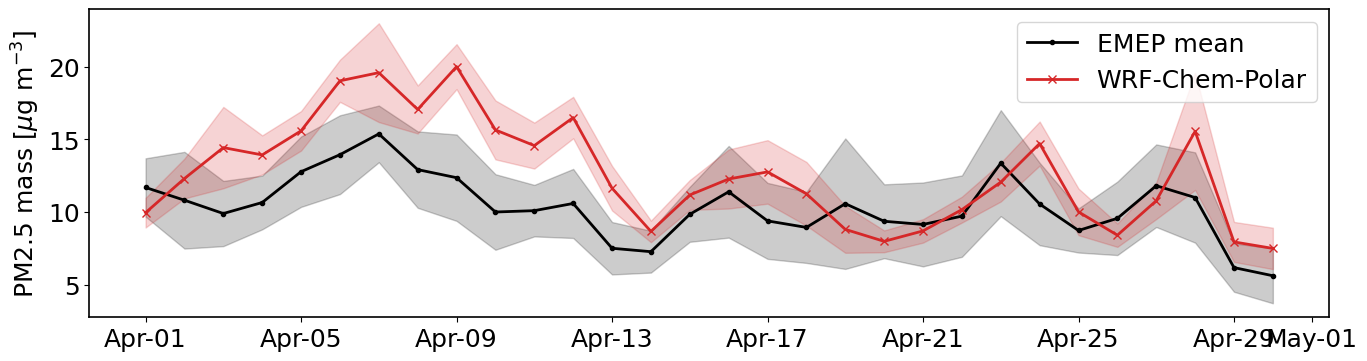

In [8]:
fig = plt.figure(figsize=(16,4))
plt.plot(emep_mean.start_time, emep_mean.pm25_masked, "k", marker=".", label="EMEP mean")
plt.fill_between(emep_mean.start_time, emep_lower.pm25_masked, emep_upper.pm25_masked, color="k", alpha=0.2)
plt.plot(
    wrfout_emep_mean.Time,
    wrfout_emep_mean.PM2_5_DRY,
    color="tab:red",
    label="WRF-Chem-Polar",
    marker="x"
)
plt.fill_between(
    wrfout_emep_mean.Time,
    wrfout_emep_lower.PM2_5_DRY,
    wrfout_emep_upper.PM2_5_DRY,
    color="tab:red",
    alpha=0.2
)
plt.legend(loc="upper right")
fig.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
plt.ylabel("PM2.5 mass [$\\mu$g m$^{{-3}}$]")
plt.savefig("figures/figure3.png", bbox_inches="tight")